# PCA loading plots to find the best subset of features

In [53]:
import sys
sys.path.append(r"C:\Users\ella_\Documents\GitHub\graphs_and_topology_for_chemistry")
sys.path.append(r"C:\Users\ella_\Documents\GitHub\icosahedron_projection")

import deepchem as dc
#from deepchem.feat import SmilesToImage

import tensorflow as tf
import os
import sys
import rdkit
import h5py
import helper_functions as h
import pandas

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.tri
import rdkit.Chem as Chem
import rdkit.Chem.AllChem as AllChem
from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors
import mpl_toolkits.mplot3d
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from collections import Counter

print("TensorFlow version: " + tf.__version__)

# topology stuff
from gtda.plotting import plot_point_cloud
from gtda.homology import VietorisRipsPersistence
from gtda.plotting import plot_diagram
from gtda.diagrams import PersistenceEntropy
from gtda.diagrams import NumberOfPoints
from gtda.diagrams import Amplitude
from sklearn.pipeline import make_union, Pipeline

# fixc this at some point
sys.path.append(r"C:\Users\ella_\Documents\GitHub\graphs_and_topology_for_chemistry")
sys.path.append(r"C:\Users\ella_\Documents\GitHub\icosahedron_projection")

#import projection
#from projection.molecule import Molecule
#from projection.pdbmolecule import PDBMolecule
#from projection.mol2molecule import Mol2Molecule

import helper_functions as h
loaders, classification_datasets, regression_datasets, metric_types = h.deepchem_dataset_dictionaries()

# change THIS

dataset_name='pdbbind'
#dataset_name='pdb'
rdkit_dataset_name = 'combined_gen_ref_v2020_exp5p0.csv'

data_dir=r'F:\Nextcloud\science\Datasets\topol_datasets'
results_dir=r"F:\Nextcloud\science\results\topology_and_graphs\d_" + dataset_name

# work
data_dir=r'C:\Users\eg16993\OneDrive - University of Bristol\Documents\Datasets\topol_datasets'



#test_file=dataset_name + '.csv'
#data_file_name=dataset_name + '_topological_features.hdf5'
#loader = loaders[dataset_name]
#make_dataset=False # whether to recalc the dataset

print(f"DeepChem version: {dc.__version__}")

############################### settings for all experiments #################

#best_con = 123.7 #multitask value   #10.22
#best_graph = 8.8 # for dtnn, u didn't run ani which is 2.86

#num_repeats= 5
#num_epochs = 500

metric_labels=['mean_squared_error','pearson_r2_score',
               'mae_score', 'rmse']


metric1 = dc.metrics.Metric(dc.metrics.mean_squared_error)
metric2 = dc.metrics.Metric(dc.metrics.pearson_r2_score)
metric3 = dc.metrics.Metric(dc.metrics.mae_score)
metrics = [metric1, metric2, metric3]
selected_metric = 2 #which metric to use for callback

Splitter = dc.splits.SingletaskStratifiedSplitter()

split_fraction=[0.8, 0.1, 0.1]


TensorFlow version: 2.7.0
DeepChem version: 2.5.0


In [54]:
#! pip install pca

In [55]:
from pca import pca

Column 'Ipc' has some really big numbers in it. I am going to drop the whole column for this analysis

In [56]:
X.columns

Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10',
       ...
       'X142', 'X143', 'X144', 'X145', 'X146', 'X147', 'X148', 'X149', 'X150',
       'X151'],
      dtype='object', length=150)

In [70]:
# what i did before
df = pd.read_csv(os.path.join(data_dir, rdkit_dataset_name))
print(len(df))
X=df.drop(df.columns[0], axis=1)
X=X.drop(X.columns[36+32], axis=1)
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.dropna(inplace=True)
print(len(X))
y=X['y']
print(len(y))
X=X.drop(X.columns[-3:],axis=1)



18765
18675
18675


#### what i did before
df = pd.read_csv(os.path.join(data_dir, rdkit_dataset_name))
print(len(df))
X=df.drop(df.columns[0], axis=1)
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.dropna(inplace=True)
print(len(X))

In [58]:
X

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X142,X143,X144,X145,X146,X147,X148,X149,X150,X151
0,0.942016,-0.000000,-1.000000,30.0,1.0,0.0,0.763516,0.296055,0.000000,3.374619,...,2.0,3.0,4.0,9.0,0.0,0.0,0.0,0.0,-2.00370,45.8406
1,0.910939,1.827833,-0.000000,29.0,5.0,1.0,0.893537,0.369272,0.087141,3.735883,...,14.0,7.0,17.0,14.0,0.0,1.0,1.0,1.0,-2.23130,62.7101
2,0.928334,1.399580,-1.000000,23.0,3.0,0.0,0.755296,0.380954,0.000000,3.052318,...,5.0,2.0,7.0,4.0,0.0,0.0,0.0,2.0,-0.45048,48.2404
3,0.921540,0.000000,-0.000000,17.0,1.0,1.0,0.765157,0.513857,0.152412,2.621312,...,3.0,2.0,3.0,3.0,0.0,0.0,0.0,1.0,1.01930,39.4466
4,0.923128,-0.000000,-0.000000,14.0,1.0,1.0,0.756832,0.473398,0.144439,2.329134,...,2.0,1.0,4.0,1.0,0.0,0.0,0.0,1.0,-0.05690,31.1947
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18760,0.945669,1.170644,8.320490,73.0,11.0,4.0,0.869389,0.511968,0.178594,5.463214,...,8.0,4.0,11.0,17.0,0.0,0.0,0.0,3.0,4.52030,152.9455
18761,0.948455,1.087610,2.481317,91.0,19.0,9.0,0.777940,0.520539,0.167160,6.090534,...,8.0,3.0,8.0,14.0,0.0,0.0,0.0,8.0,8.63550,206.2665
18762,0.929714,1.578693,-0.000000,30.0,4.0,1.0,0.903770,0.383501,0.032944,3.538430,...,4.0,3.0,6.0,5.0,0.0,2.0,2.0,2.0,0.79680,61.5932
18763,0.948827,1.095855,2.570798,91.0,20.0,8.0,0.768362,0.517390,0.163521,6.079536,...,8.0,3.0,8.0,14.0,0.0,0.0,0.0,8.0,8.63550,206.2665


In [59]:
import pandas as pd
import numpy as np

# Assuming you have a DataFrame called X
# Let's say the value you're looking for is 42
value = egg

# Finding the row and column indices where the value is located
row_indices, col_indices = np.where(X == value)

# Printing the result
if len(row_indices) > 0:
    for row, col in zip(row_indices, col_indices):
        print(f"Value {value} found at row {row} and column {col}")
else:
    print(f"Value {value} not found in the DataFrame.")



Value 96146.8359375 found at row 9837 and column 2


In [60]:
X.columns[32]

'X33'

In [61]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Assuming you have a DataFrame called X
# Perform standard scaling on X
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert the scaled array back to a DataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Now you can use X_scaled_df for PCA


<AxesSubplot:>

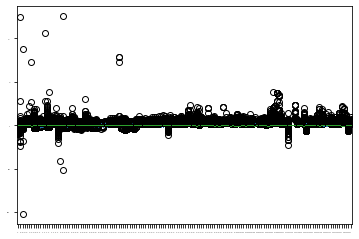

In [62]:
X_scaled_df.plot.box()

Text(0.5, 0, 'Value')

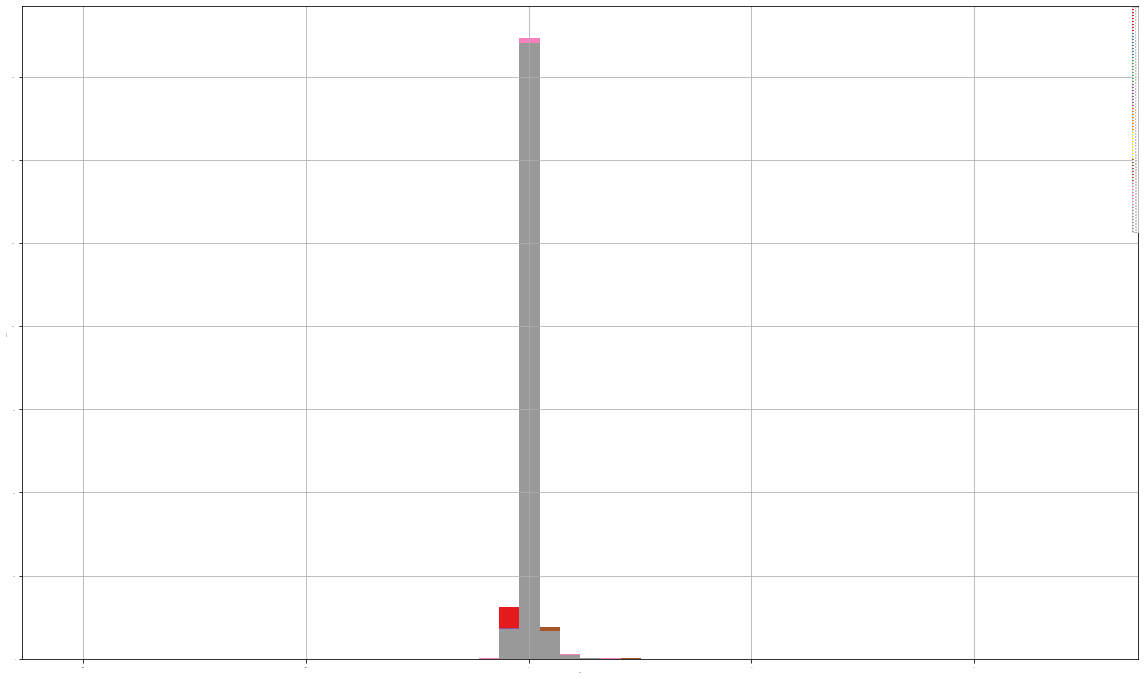

In [63]:
# Make histogram to visualize the spread of the data points.
fig, ax = plt.subplots(figsize=(20, 12))
X_scaled_df.plot.hist(bins=50, cmap='Set1', ax=ax)
ax.grid(True); ax.set_xlabel('Value')
#plt.xlim[0:]

In [74]:
# Initialize
model = pca(normalize=False, n_components=None)
# Fit transform data
results = model.fit_transform(X_scaled_df)
# Extract the most informative features
results['topfeat']
results['topfeat'].to_csv('all_gen_ref_2020_top_feat_pca_loading.csv')

[pca] >n_components is set to 149
[pca] >Extracting column labels from dataframe.
[pca] >Extracting row labels from dataframe.
[pca] >The PCA reduction is performed on the [150] columns of the input dataframe.
[pca] >Fit using PCA.
[pca] >Compute loadings and PCs.
[pca] >Compute explained variance.
[pca] >Outlier detection using Hotelling T2 test with alpha=[0.05] and n_components=[149]
[pca] >Multiple test correction applied for Hotelling T2 test: [fdr_bh]
[pca] >Outlier detection using SPE/DmodX with n_std=[3]


In [65]:
results

{'loadings':              X1            X2            X3            X4            X5  \
 PC1    0.087643  1.737548e-04  5.516900e-05  1.283366e-01  1.203480e-01   
 PC2    0.042679 -1.009229e-03 -1.313079e-04 -5.988722e-03  2.305798e-02   
 PC3    0.014741  5.693432e-03 -1.208185e-03 -7.788172e-03 -3.410922e-02   
 PC4    0.044397 -2.204703e-03 -2.506781e-04 -1.272397e-02  2.095140e-02   
 PC5   -0.137367 -4.487468e-03 -2.152721e-03 -4.457384e-02 -4.236852e-02   
 ...         ...           ...           ...           ...           ...   
 PC145  0.000000  1.664311e-18  2.953926e-18  6.400321e-17 -5.728664e-17   
 PC146  0.000000 -1.051107e-18 -4.119920e-19 -1.305533e-16  5.303324e-17   
 PC147  0.000000 -1.402162e-19 -5.734506e-19  7.712743e-17  4.112308e-17   
 PC148  0.000000  2.929353e-19  3.273869e-19 -3.324699e-17 -1.794857e-17   
 PC149 -0.000000  6.009391e-20  7.410604e-19  1.762680e-16  5.103141e-17   
 
                  X6            X7            X8            X9           X

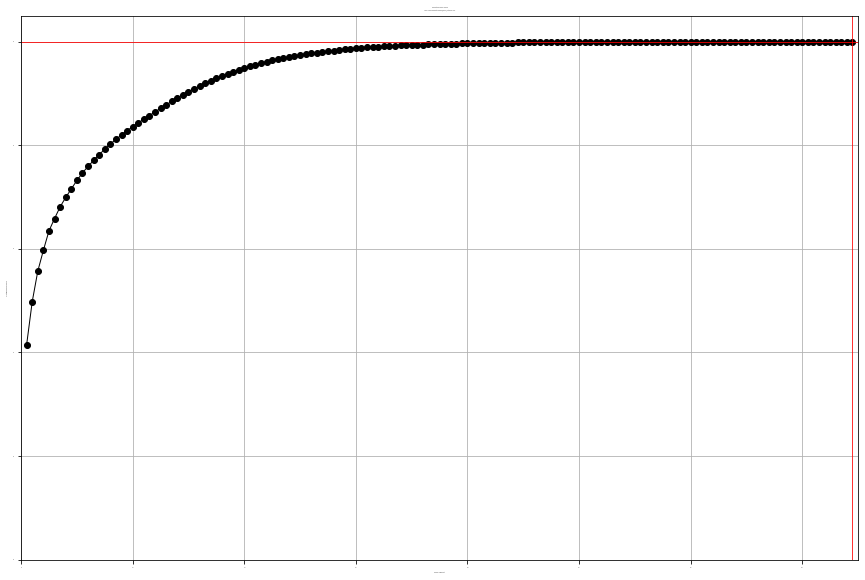

(<Figure size 1080x720 with 1 Axes>,
 <AxesSubplot:title={'center':'Cumulative explained variance\n 149 Principal Components explain [100.0%] of the variance.'}, xlabel='Principle Component', ylabel='Percentage explained variance'>)

<Figure size 432x288 with 0 Axes>

In [66]:
# Plot the explained variance
model.plot()

[pca] >Plot PC1 vs PC2 with loadings.


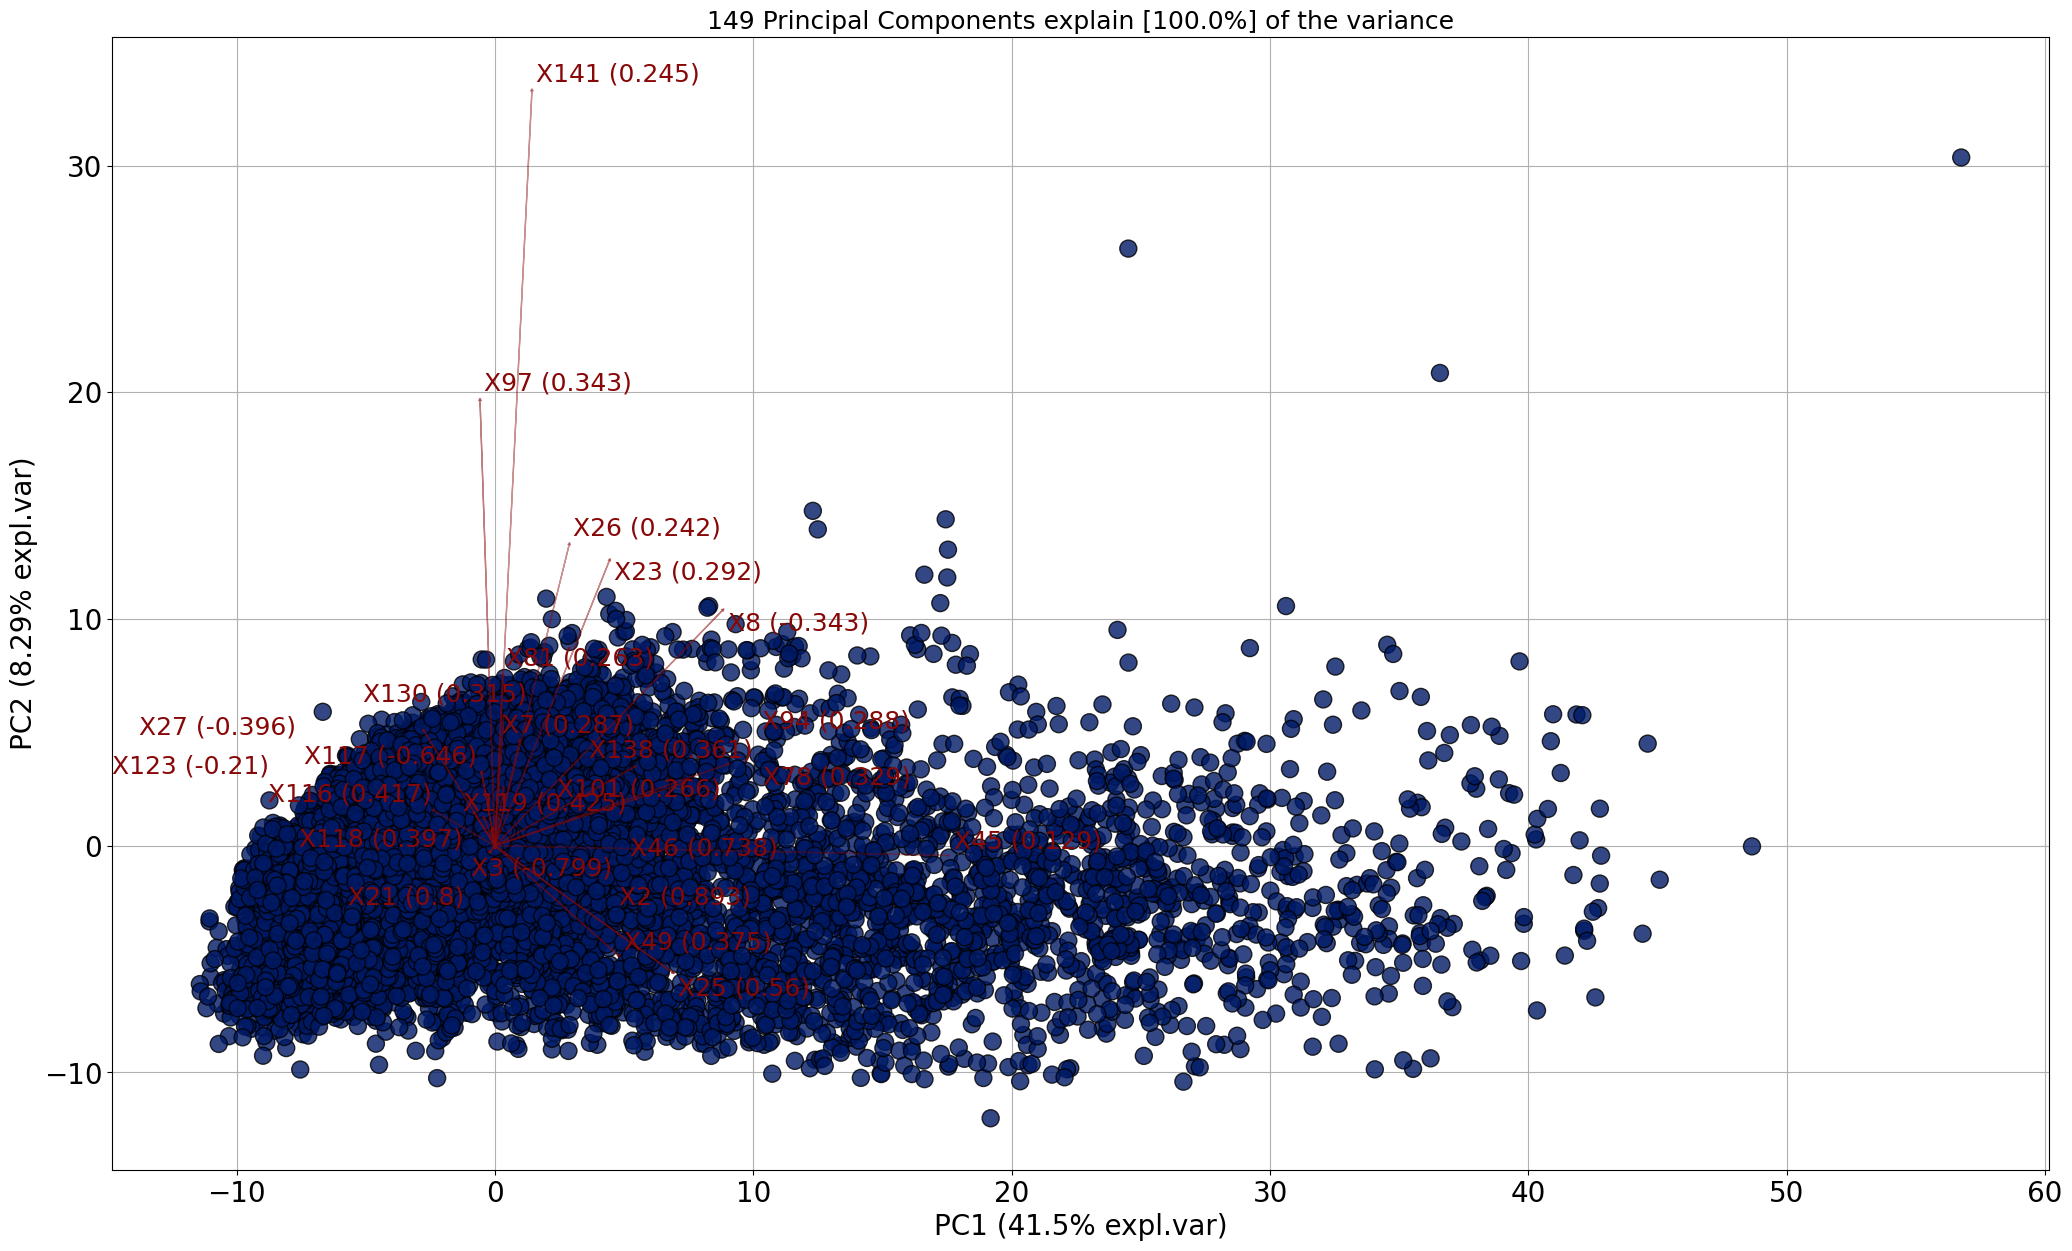

In [67]:
# Biplot with the loadings
ax = model.biplot(legend=False)

ValueError: 'c' argument has 18669 elements, which is inconsistent with 'x' and 'y' with size 18675.

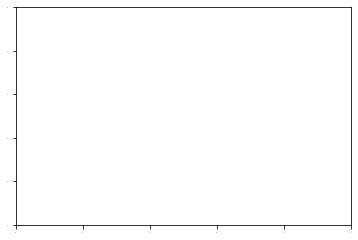

In [71]:

y_classed=[]
for i in y:
    if i < 2:
        y_classed.append(str(1))
    elif i >=2 and i< 3:
        y_classed.append(str(2))
    elif i >=3 and i< 4:
        y_classed.append(str(3))
    elif i >=4 and i< 5:
        y_classed.append(str(4))
    elif i >=5 and i< 6:
        y_classed.append(str(5))
    elif i >=6 and i< 7:
        y_classed.append(str(6))
    elif i >=7 and i< 8:
        y_classed.append(str(7))
    elif i >=8 and i< 9:
        y_classed.append(str(8))
    elif i >=9 and i< 10:
        y_classed.append(str(9))
    elif i >=10 and i< 11:
        y_classed.append(str(10))
    elif i >=11 and i< 12:
        y_classed.append(str(11))
    elif i >=12 and i< 13:
        y_classed.append(str(12))
    elif i > 13:
        y_classed.append(str(13))
from sklearn import decomposition
y_classed_int = [int(x) for x in y_classed]
# PCA (How I tend to set it up)
Mod_PCA = decomposition.PCA(40)
DF_PCA = pd.DataFrame(Mod_PCA.fit_transform(X_scaled_df), 
                      columns=["PC%d" % k for k in range(1,40 + 1)]).iloc[:,:2]

# Cleaning the biplot by removing the scatter, and looking only at the top 3 features.

#ax=model.biplot(n_feat=40, legend=False, label=False, cmap=None)

plt.scatter(x=DF_PCA["PC1"], y=DF_PCA["PC2"], c=y_classed_int)

[pca]> [WARNING]: De parameter <label> is deprecated and will not be supported in future version.
[pca] >Plot PC1 vs PC2 with loadings.


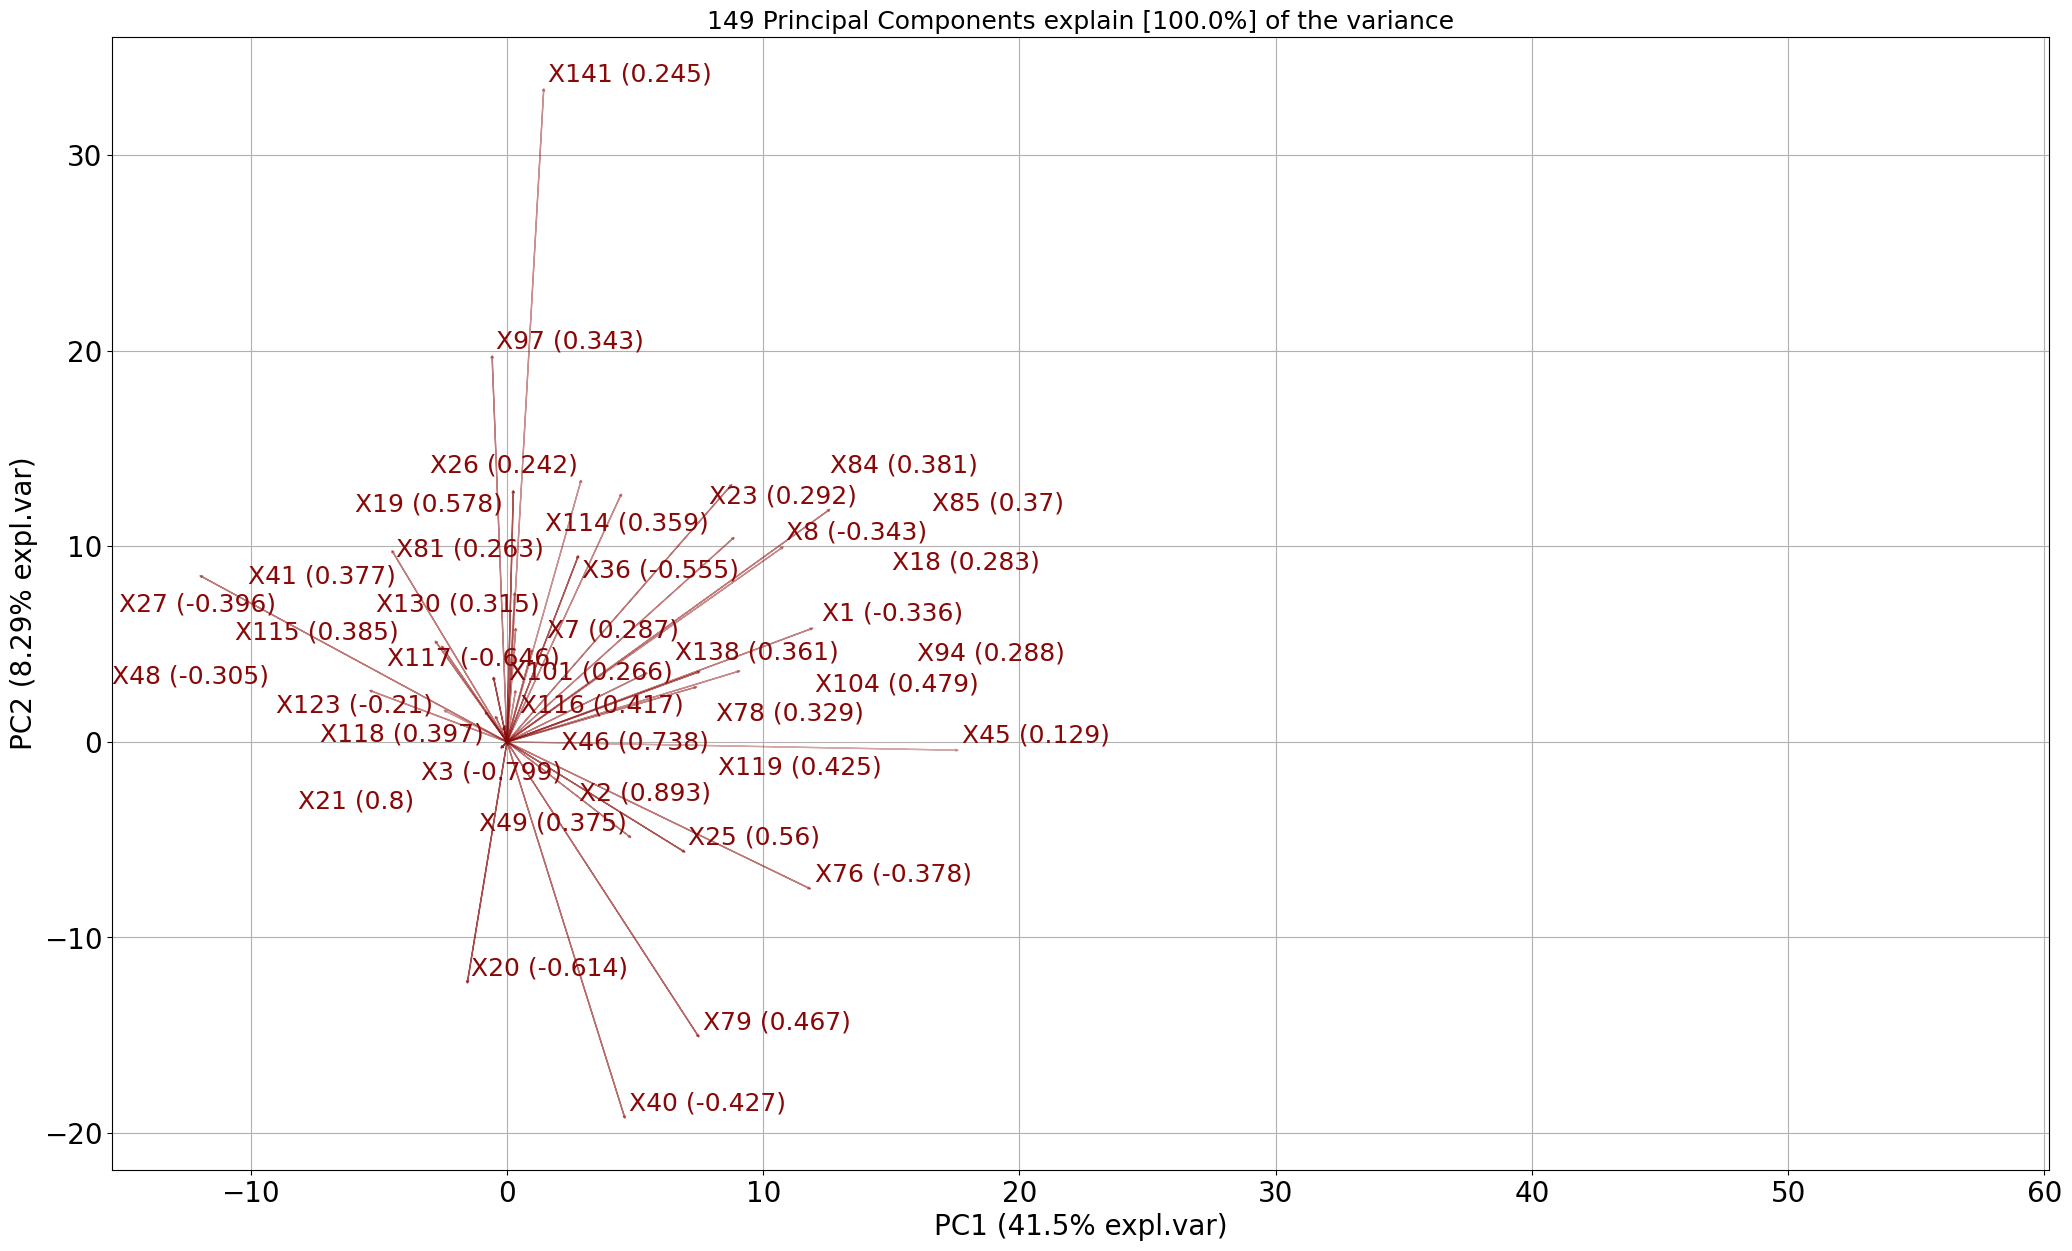

In [43]:
# Cleaning the biplot by removing the scatter, and looking only at the top 3 features.
ax = model.biplot(n_feat=40, legend=False, label=False, cmap=None)


[pca] >Plot PC1 vs PC2 with loadings.


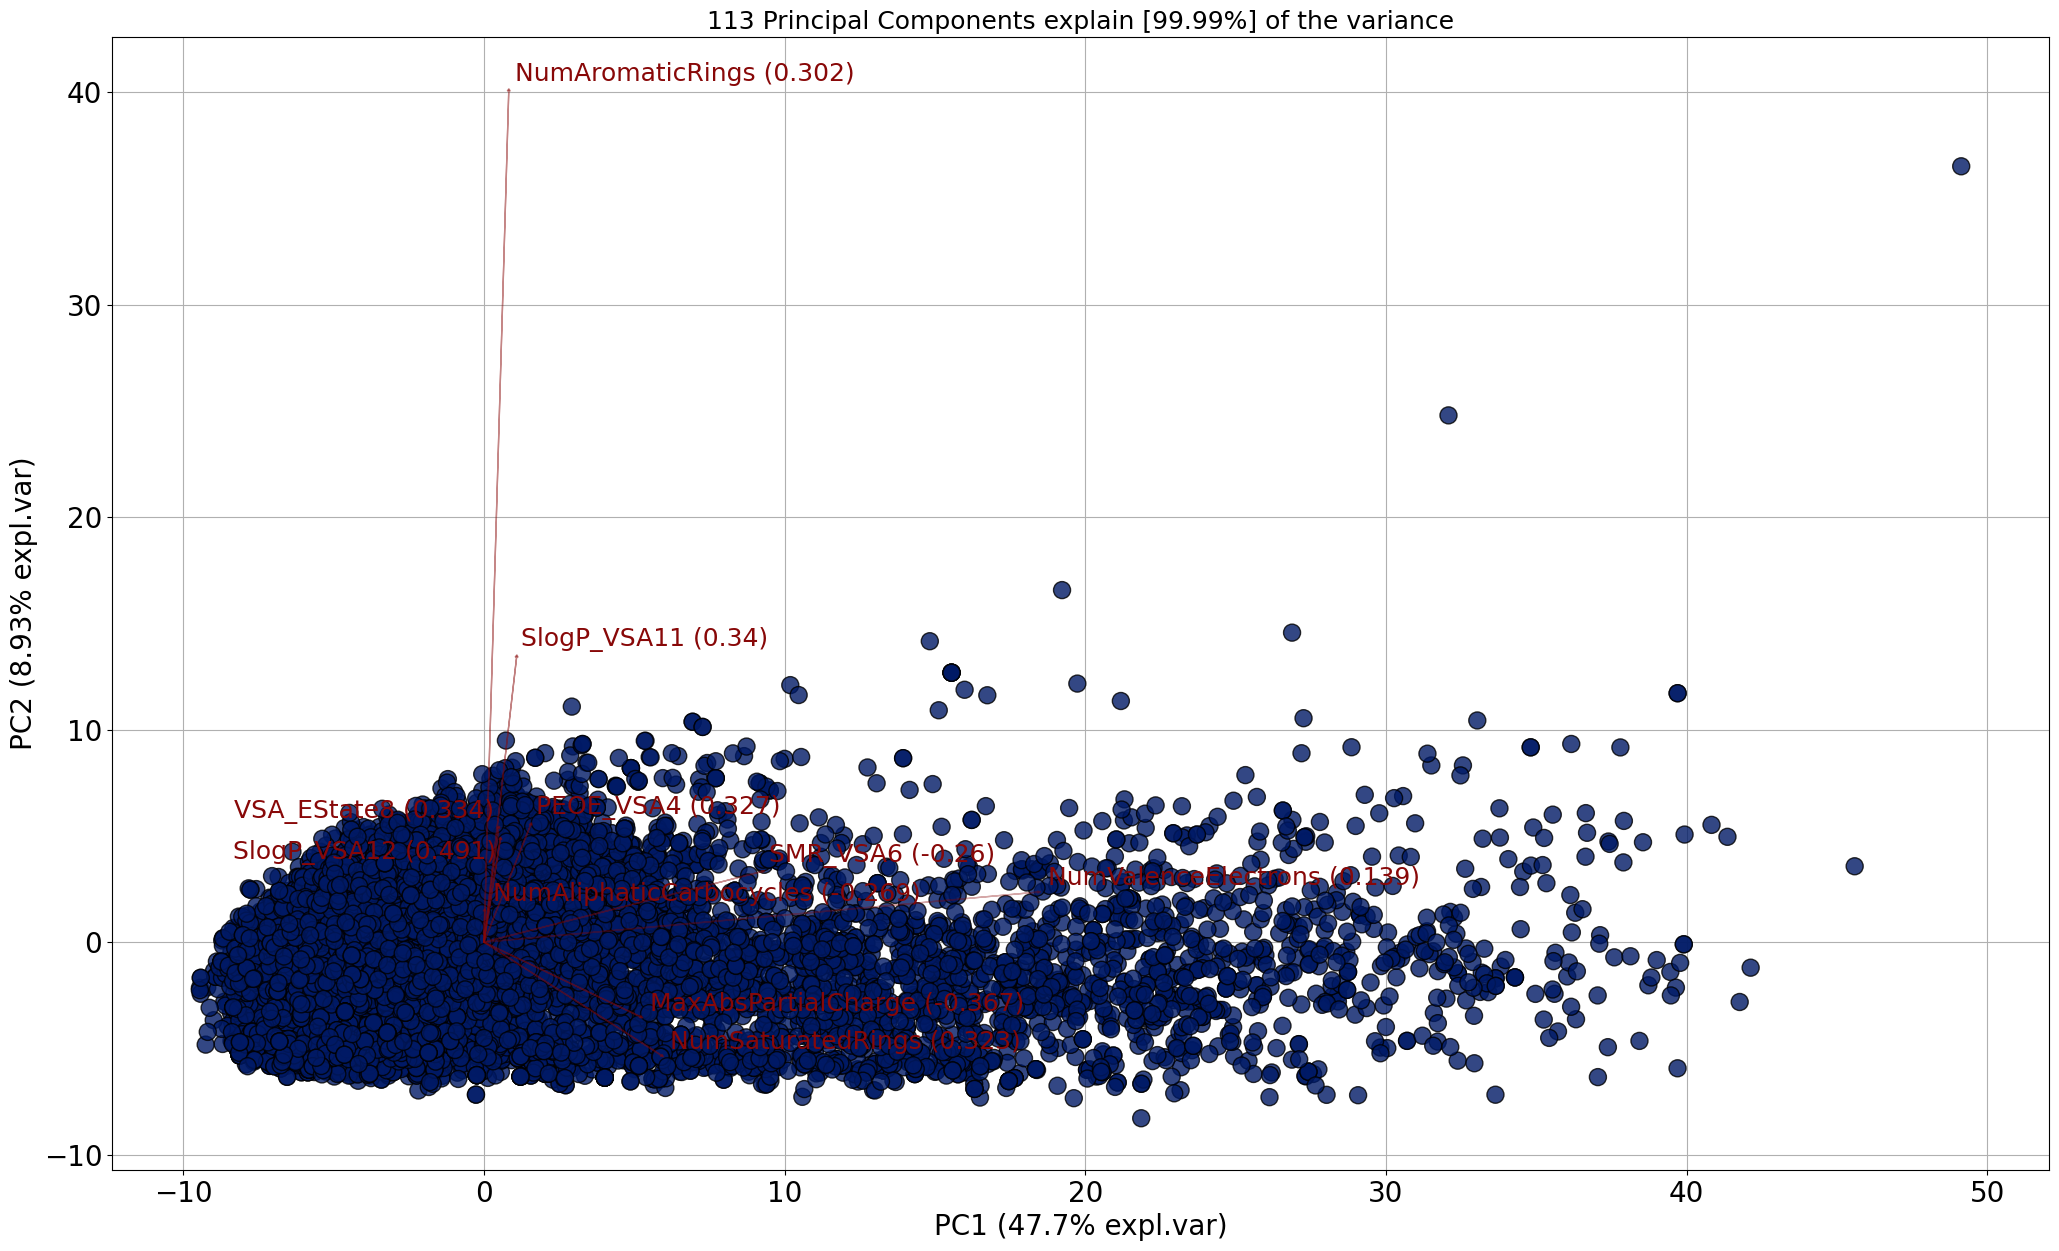

In [130]:
# Cleaning the biplot by removing the scatter, and looking only at the top 3 features.
ax = model.biplot(n_feat=10, legend=False, cmap="Set2")


[pca]> [WARNING]: De parameter <label> is deprecated and will not be supported in future version.
[pca] >Plot PC1 vs PC2 with loadings.


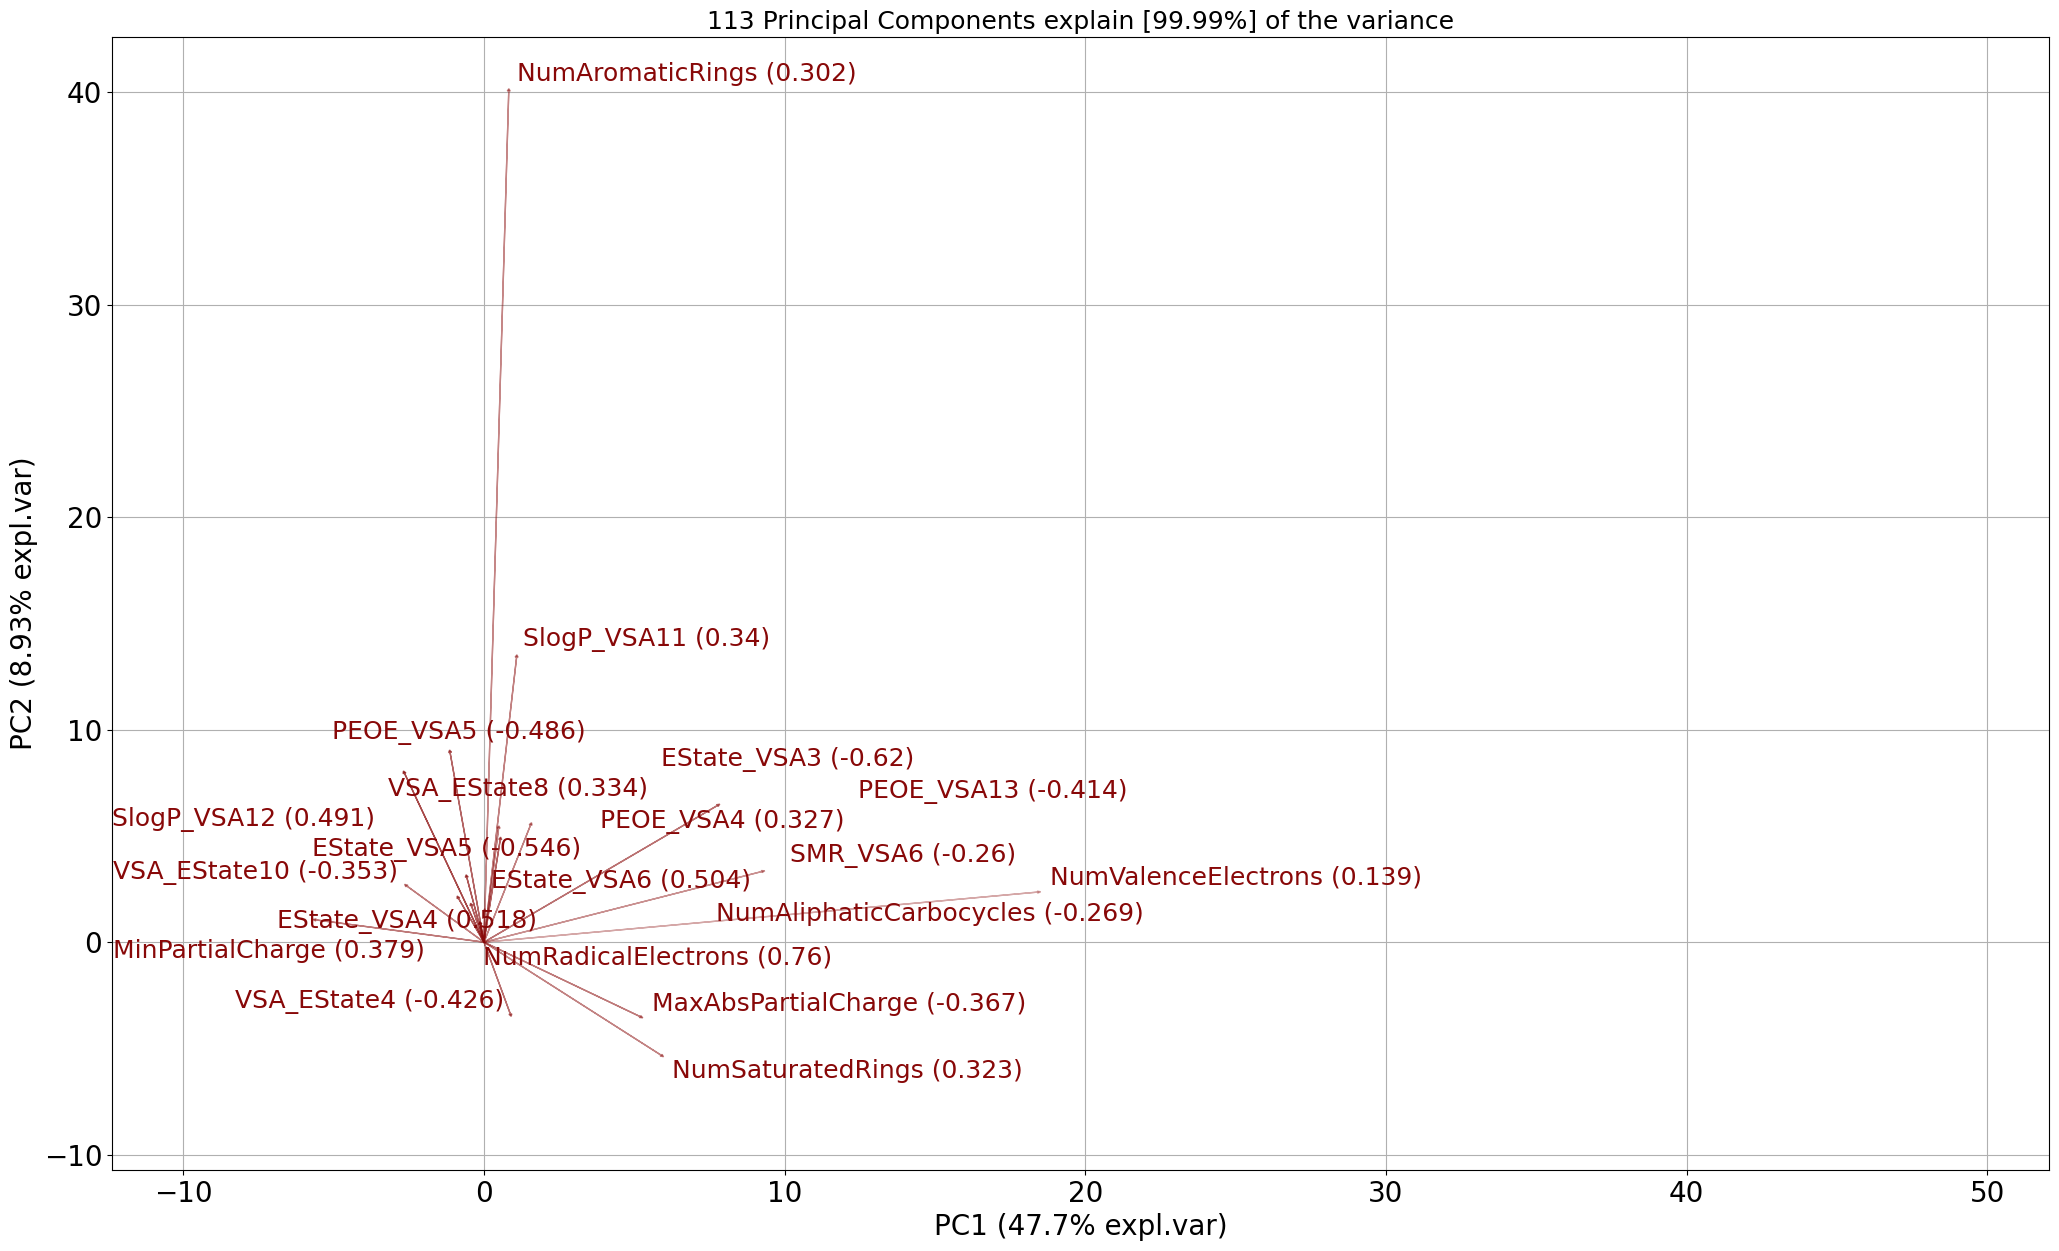

In [124]:
# Cleaning the biplot by removing the scatter, and looking only at the top 3 features.
ax = model.biplot(n_feat=20, legend=False, label=False, cmap=None)


[pca]> [WARNING]: De parameter <label> is deprecated and will not be supported in future version.
[pca] >Plot PC1 vs PC2 vs PC3 with loadings.


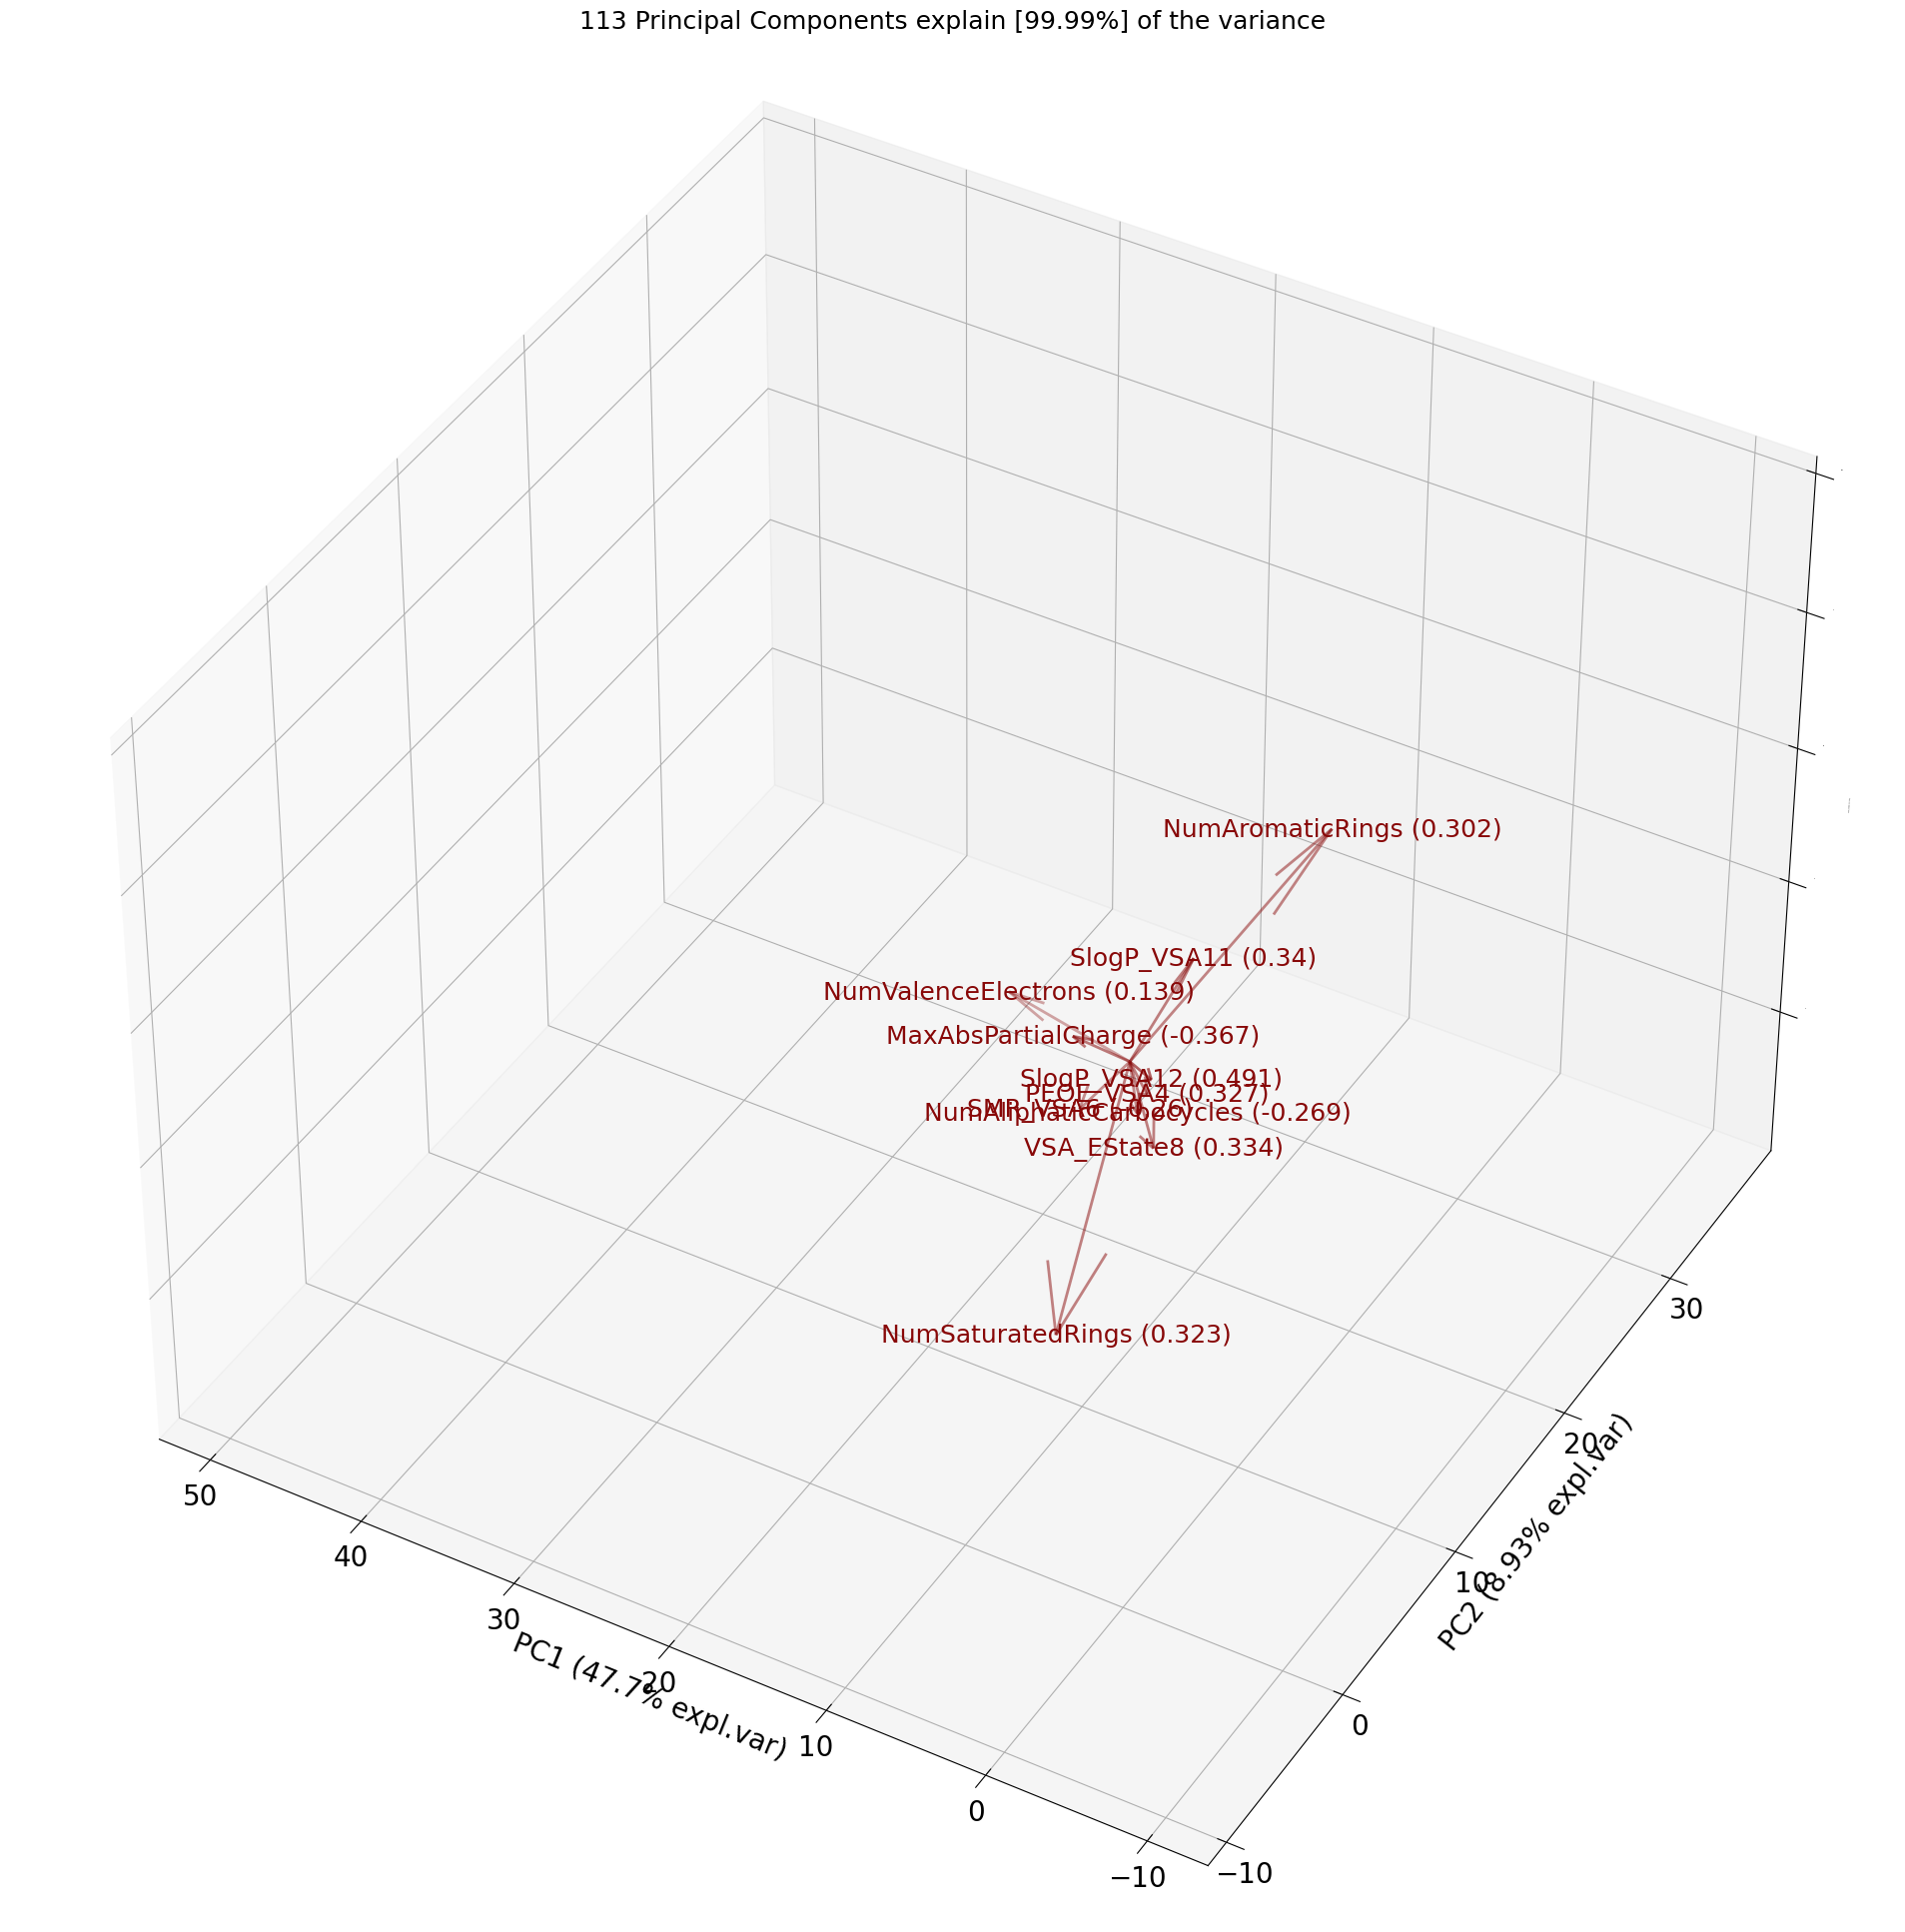

(<Figure size 3000x2500 with 1 Axes>,
 <Axes3DSubplot:title={'center':'113 Principal Components explain [99.99%] of the variance'}, xlabel='PC1 (47.7% expl.var)', ylabel='PC2 (8.93% expl.var)'>)

In [125]:
# Make plot with 3 dimensions
model.biplot3d(n_feat=10, legend=False, label=False, cmap=None)